# Task 2 – Unemployment Analysis with Python

## Objective
Perform exploratory data analysis on unemployment data to identify **regional and temporal trends** and examine the impact of the **COVID-19 period** on unemployment rates in India.

### Tech Stack
- Python
- pandas
- matplotlib
- seaborn
- Jupyter Notebook

### Dataset Used
This notebook uses **`Unemployment in India.csv`** from the attached ZIP file. The ZIP also contains `Unemployment_Rate_upto_11_2020.csv`, but the `Unemployment in India.csv` file is preferred because it contains the longer May 2019–June 2020 period and an `Area` column.

> **Note:** The dataset does not contain a direct "Employment Rate (%)" column. For the required correlation analysis, employment rate is derived as:
> **Employment Rate = Labour Participation Rate − Unemployment Rate**
> This is a standard identity when both rates use the same working-age population base.


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

sns.set_theme(style="whitegrid")
print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Load the Dataset

In [2]:
# Load the dataset
# The notebook first looks for the preferred CSV in the current folder.
# If it is not found, it uses the other CSV included in the attached ZIP.
from pathlib import Path

preferred = Path("Unemployment in India.csv")
fallback = Path("Unemployment_Rate_upto_11_2020.csv")

if preferred.exists():
    DATA_FILE = preferred
elif fallback.exists():
    DATA_FILE = fallback
else:
    raise FileNotFoundError(
        "Place 'Unemployment in India.csv' (or the fallback CSV) in the same folder as this notebook."
    )

df = pd.read_csv(DATA_FILE)

print("Dataset loaded:", DATA_FILE)
print("Shape:", df.shape)
df.head()


Dataset loaded: Unemployment in India.csv
Shape: (768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.00,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.00,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.00,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.00,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.00,44.68,Rural


## 2. Inspect the Data: Shape, Columns, Types and Missing Values

In [3]:
# Remove accidental leading/trailing spaces from column names
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Shape: (768, 7)

Columns:
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']

Data types:
Region                                      object
Date                                        object
Frequency                                   object
Estimated Unemployment Rate (%)            float64
Estimated Employed                         float64
Estimated Labour Participation Rate (%)    float64
Area                                        object
dtype: object

Missing values:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

Duplicate rows: 27


### Data-cleaning observation
The attached CSV contains some completely blank rows. These rows do not represent unemployment observations, so they can be safely removed. Duplicate records are also removed before analysis. The `Date` column is converted to datetime so that monthly and time-series analysis can be performed correctly.

In [4]:
# Remove completely blank rows and duplicate records
df = df.dropna(how='all').drop_duplicates().copy()

# Convert date to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Convert numeric columns explicitly
numeric_columns = [
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove rows where essential analysis fields are missing
df = df.dropna(subset=[
    'Region', 'Date',
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)'
]).copy()

# Derived employment rate for correlation analysis
df['Employment Rate (%)'] = (
    df['Estimated Labour Participation Rate (%)']
    - df['Estimated Unemployment Rate (%)']
)

# Helpful time columns
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name().str[:3]
df['Month_Num'] = df['Date'].dt.month

print("Cleaned shape:", df.shape)
print("Date range:", df['Date'].min().date(), "to", df['Date'].max().date())
print("Regions:", df['Region'].nunique())
df.head()


Cleaned shape: (740, 11)
Date range: 2019-05-31 to 2020-06-30
Regions: 28


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Employment Rate (%),Year,Month,Month_Num
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.00,43.24,Rural,39.59,2019,May,5
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.00,42.05,Rural,39.00,2019,Jun,6
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.00,43.50,Rural,39.75,2019,Jul,7
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.00,43.97,Rural,40.65,2019,Aug,8
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.00,44.68,Rural,39.51,2019,Sep,9


## 3. Region-wise Average Unemployment Rate

This analysis calculates the average unemployment rate for each state/region. Higher values indicate regions that experienced greater average unemployment during the dataset period.

In [5]:
region_avg = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
      .mean()
      .sort_values(ascending=False)
)

region_avg.to_frame(name='Average Unemployment Rate (%)').round(2)


,Average Unemployment Rate (%)
Region,
Tripura,28.35
Haryana,26.28
Jharkhand,20.58
Bihar,18.92
Himachal Pradesh,18.54
Delhi,16.50
Jammu & Kashmir,16.19
Chandigarh,15.99
Rajasthan,14.06


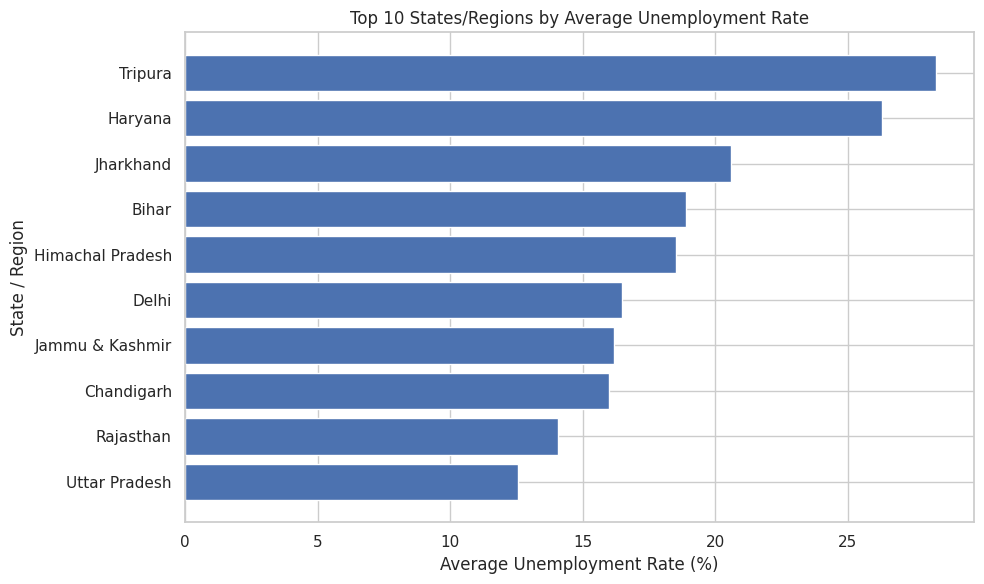

In [6]:
# Bar chart: Top 10 states/regions with highest average unemployment rate
top10 = region_avg.head(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top10.index, top10.values)
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State / Region')
plt.title('Top 10 States/Regions by Average Unemployment Rate')
plt.tight_layout()
plt.show()


### Observation
The highest average unemployment rates are concentrated in a smaller group of regions. In this dataset, **Tripura, Haryana and Jharkhand** are among the regions with the highest averages. Regional differences suggest that unemployment was not evenly distributed across India.

## 4. Month-wise Unemployment Trend

In [7]:
# Average unemployment rate by calendar month
month_avg = (
    df.groupby(['Month_Num', 'Month'])['Estimated Unemployment Rate (%)']
      .mean()
      .reset_index()
      .sort_values('Month_Num')
)

month_avg


,Month_Num,Month,Estimated Unemployment Rate (%)
0,1,Jan,9.95
1,2,Feb,9.96
2,3,Mar,10.70
3,4,Apr,23.64
4,5,May,16.65
5,6,Jun,10.55
6,7,Jul,9.03
7,8,Aug,9.64
8,9,Sep,9.05
9,10,Oct,9.90


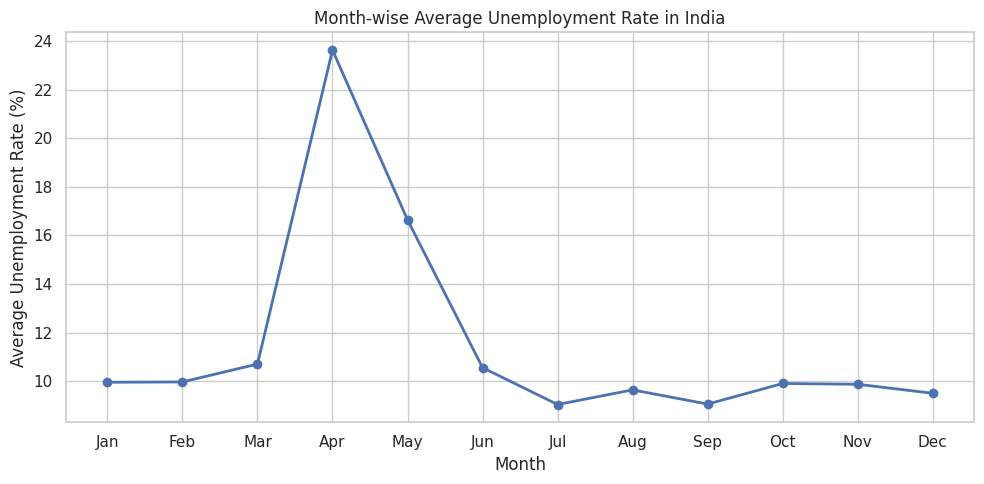

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(month_avg['Month'], month_avg['Estimated Unemployment Rate (%)'],
         marker='o', linewidth=2)
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')
plt.title('Month-wise Average Unemployment Rate in India')
plt.tight_layout()
plt.show()


### Observation
The month-wise pattern shows a clear rise in unemployment during **April and May 2020**, coinciding with the major COVID-19 disruption. The average unemployment rate was much lower in most pre-COVID months and then increased sharply during the lockdown period.

## 5. Time-Series Analysis for Major States/Regions

In [9]:
# Select three major, widely represented states for comparison.
# If any is absent, the code automatically uses the first three available regions.
preferred_states = ['Maharashtra', 'Uttar Pradesh', 'West Bengal']
available_states = [s for s in preferred_states if s in df['Region'].unique()]

if len(available_states) < 3:
    available_states = df['Region'].value_counts().head(3).index.tolist()

print("States/regions selected:", available_states)


States/regions selected: ['Maharashtra', 'Uttar Pradesh', 'West Bengal']


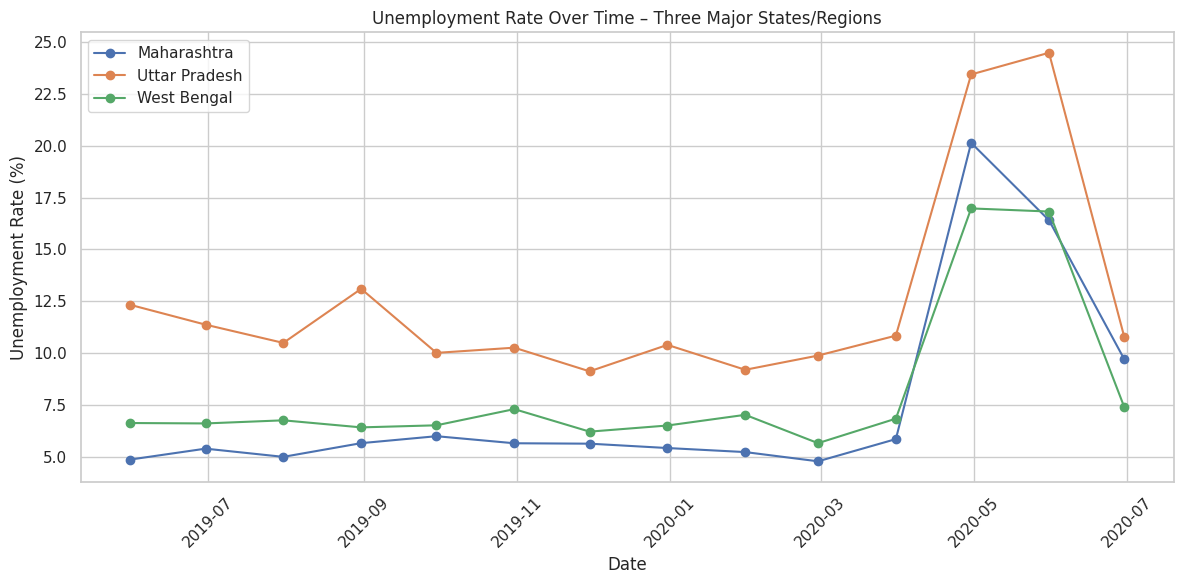

In [10]:
plt.figure(figsize=(12, 6))

for state in available_states:
    state_data = (
        df[df['Region'] == state]
        .groupby('Date')['Estimated Unemployment Rate (%)']
        .mean()
        .sort_index()
    )
    plt.plot(state_data.index, state_data.values, marker='o', label=state)

plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.title('Unemployment Rate Over Time – Three Major States/Regions')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Observation
The three selected states/regions show different unemployment patterns, but all can be compared around the same COVID-19 period. The sharpest movements occur around **April–May 2020**, showing that the pandemic and associated economic restrictions had a strong short-term effect on unemployment.

## 6. Correlation Heatmap: Unemployment, Employment and Labour Participation

In [11]:
# Correlation matrix
corr_cols = [
    'Estimated Unemployment Rate (%)',
    'Employment Rate (%)',
    'Estimated Labour Participation Rate (%)'
]

corr_matrix = df[corr_cols].corr()
corr_matrix


,Estimated Unemployment Rate (%),Employment Rate (%),Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.00,-0.80,0.00
Employment Rate (%),-0.80,1.00,0.60
Estimated Labour Participation Rate (%),0.00,0.60,1.00


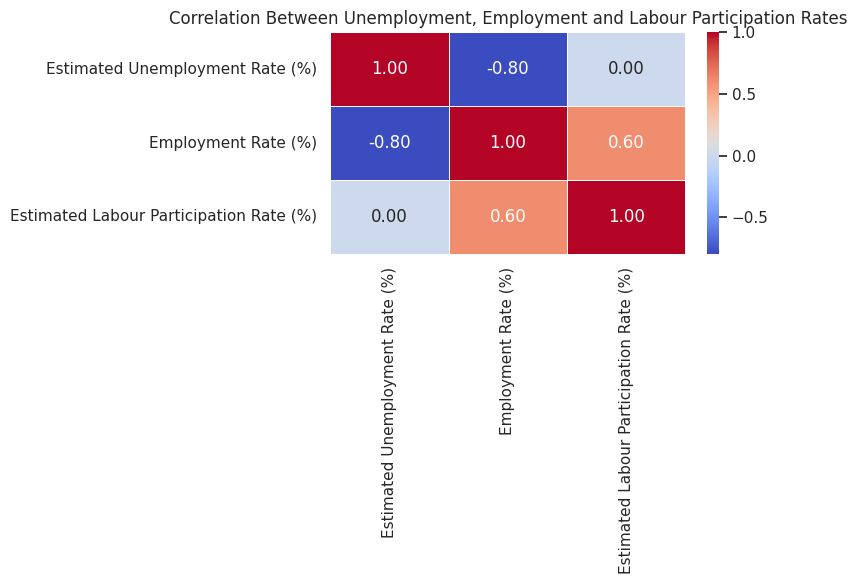

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Between Unemployment, Employment and Labour Participation Rates')
plt.tight_layout()
plt.show()


### Observation
The derived employment rate has a strong negative relationship with unemployment rate because a higher unemployment rate generally leaves a smaller share of the working-age population employed. Labour participation rate should be interpreted separately because participation measures involvement in the labour force, not whether that participation results in employment.

**Important:** Correlation describes association, not causation.

## 7. Pre-COVID vs COVID-Period Comparison

In [13]:
# Split the dataset at 1 March 2020.
# Here, "COVID period" means the pandemic/lockdown period in the available data,
# not a claim that the pandemic had completely ended afterward.
cutoff = pd.Timestamp('2020-03-01')

df['Period'] = np.where(
    df['Date'] < cutoff,
    'Pre-COVID (before Mar 2020)',
    'COVID period (Mar-Jun 2020)'
)

period_summary = (
    df.groupby('Period')[
        [
            'Estimated Unemployment Rate (%)',
            'Employment Rate (%)',
            'Estimated Labour Participation Rate (%)'
        ]
    ]
    .mean()
    .round(2)
)

period_summary


,Estimated Unemployment Rate (%),Employment Rate (%),Estimated Labour Participation Rate (%)
Period,,,
COVID period (Mar-Jun 2020),17.77,21.56,39.33
Pre-COVID (before Mar 2020),9.51,34.38,43.89


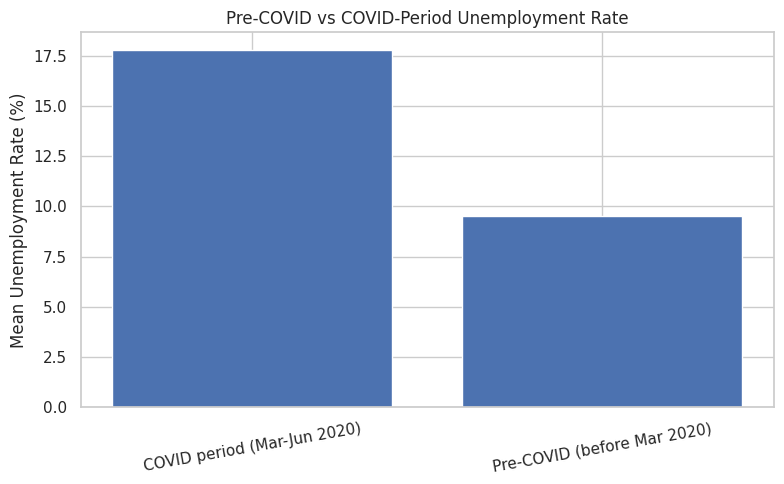

In [14]:
# Visual comparison of unemployment rate
plt.figure(figsize=(8, 5))
plt.bar(period_summary.index, period_summary['Estimated Unemployment Rate (%)'])
plt.ylabel('Mean Unemployment Rate (%)')
plt.title('Pre-COVID vs COVID-Period Unemployment Rate')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


### Observation
The average unemployment rate increased substantially during the COVID period. In this dataset, the mean unemployment rate was approximately **9.51% before March 2020** and **17.77% during March–June 2020**. This is an increase of about **8.26 percentage points**, indicating a major labour-market shock during the pandemic period.

The average labour participation rate also decreased, while the derived employment rate fell, reinforcing the evidence of disruption in employment conditions.

## 8. Key Findings

In [15]:
# Print concise numerical findings for the final report
highest_region = region_avg.index[0]
highest_rate = region_avg.iloc[0]

pre_rate = period_summary.loc['Pre-COVID (before Mar 2020)', 'Estimated Unemployment Rate (%)']
covid_rate = period_summary.loc['COVID period (Mar-Jun 2020)', 'Estimated Unemployment Rate (%)']

print(f"1. Highest average unemployment region: {highest_region} ({highest_rate:.2f}%)")
print(f"2. Pre-COVID average unemployment rate: {pre_rate:.2f}%")
print(f"3. COVID-period average unemployment rate: {covid_rate:.2f}%")
print(f"4. Increase: {covid_rate - pre_rate:.2f} percentage points")
print(f"5. Highest month-wise average in the available data: "
      f"{month_avg.loc[month_avg['Estimated Unemployment Rate (%)'].idxmax(), 'Month']} "
      f"({month_avg['Estimated Unemployment Rate (%)'].max():.2f}%)")


1. Highest average unemployment region: Tripura (28.35%)
2. Pre-COVID average unemployment rate: 9.51%
3. COVID-period average unemployment rate: 17.77%
4. Increase: 8.26 percentage points
5. Highest month-wise average in the available data: Apr (23.64%)


## 9. Conclusion

The exploratory analysis shows three major patterns:

1. **Regional variation:** Average unemployment differs considerably across Indian states/regions.
2. **Temporal variation:** Unemployment was relatively stable around the pre-COVID period but increased sharply during April–May 2020.
3. **COVID-19 impact:** The average unemployment rate rose from about **9.51% pre-COVID to 17.77% during the COVID period** in this dataset.

Overall, the analysis demonstrates how pandas can be used for data cleaning and aggregation, while matplotlib and seaborn can reveal regional, temporal and correlation-based patterns.

### Submission checklist
- [x] Dataset loaded
- [x] Shape, null values and data types inspected
- [x] Data cleaning and date conversion
- [x] Region-wise average unemployment
- [x] Month-wise trend
- [x] Time-series line chart for 3 states/regions
- [x] Top 10 bar chart
- [x] Correlation heatmap
- [x] Pre-COVID vs COVID-period comparison
- [x] Written observations between charts
- [x] Clean and commented notebook
